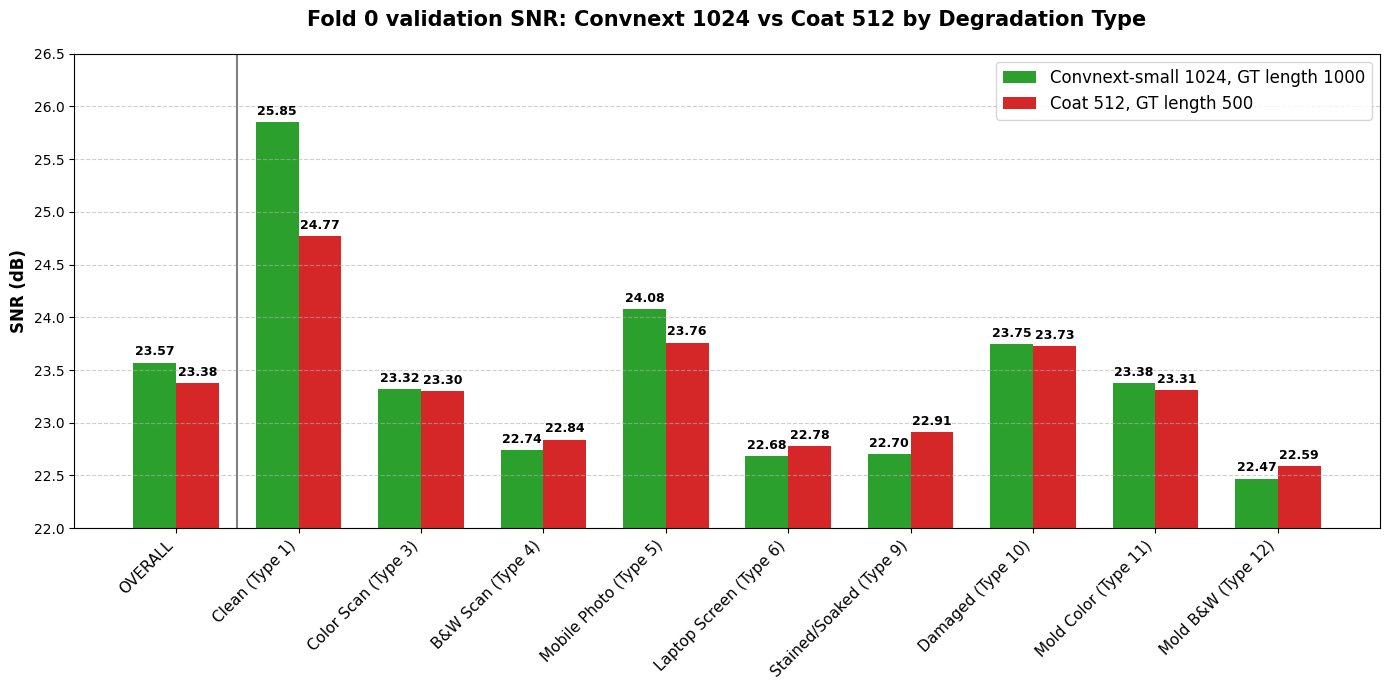

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data from the table (Single-line labels for rotation)
labels = [
    'OVERALL', 
    'Clean (Type 1)', 
    'Color Scan (Type 3)', 
    'B&W Scan (Type 4)', 
    'Mobile Photo (Type 5)', 
    'Laptop Screen (Type 6)', 
    'Stained/Soaked (Type 9)', 
    'Damaged (Type 10)', 
    'Mold Color (Type 11)', 
    'Mold B&W (Type 12)'
]

convnext_1024 = [23.57, 25.85, 23.32, 22.74, 24.08, 22.68, 22.70, 23.75, 23.38, 22.47]
coat_512 =      [23.38, 24.77, 23.30, 22.84, 23.76, 22.78, 22.91, 23.73, 23.31, 22.59]

x = np.arange(len(labels))
width = 0.35

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(14, 7))

# 3. Create the grouped bars
rects1 = ax.bar(x - width/2, convnext_1024, width, label='Convnext-small 1024, GT length 1000', color='#2ca02c')
rects2 = ax.bar(x + width/2, coat_512, width, label='Coat 512, GT length 500', color='#d62728')

# 4. Customizing the plot
ax.set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
ax.set_title('Fold 0 validation SNR: Convnext 1024 vs Coat 512 by Degradation Type', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)

# --- THE FIX: Rotated Labels ---
# 'rotation=45' tilts the text, and 'ha=right' aligns the text end directly under the tick mark
ax.set_xticklabels(labels, fontsize=11, rotation=45, ha='right')

ax.legend(fontsize=12, loc='upper right')

# Add grid and set y-limit to focus on differences
ax.set_ylim([22.0, 26.5])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Add a vertical separator line to distinguish 'Overall' from specific categories
ax.axvline(x=0.5, color='gray', linestyle='-', linewidth=1.5)

# 5. Add value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()